# Práctica 4: Razonamiento Basado en Casos con CBRkit

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

---

## Introducción

El **Razonamiento Basado en Casos (CBR)** es un paradigma de IA que resuelve nuevos problemas reutilizando soluciones de problemas similares del pasado. El ciclo CBR se compone de cuatro etapas:

1. **Retrieve** – Recuperar los casos más similares al problema actual.
2. **Reuse** – Adaptar la solución del caso recuperado al nuevo problema.
3. **Revise** – Evaluar y corregir la solución propuesta.
4. **Retain** – Almacenar el nuevo caso resuelto en la base de casos.

En esta práctica trabajaremos con la librería **CBRkit** para construir un sistema CBR aplicado a la **recomendación de coches de segunda mano**. Dado el perfil de un usuario que busca un coche, el sistema recuperará los vehículos más similares de la base de casos y adaptará el precio estimado.


---

## Dataset: Used Cars

Utilizaremos un subconjunto del dataset de coches de segunda mano disponible en Kaggle:  
🔗 https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

Cada caso representa un vehículo con los siguientes atributos:

| Atributo | Tipo | Descripción |
|---|---|---|
| `price` | Numérico | Precio en dólares (solución / target) |
| `year` | Numérico | Año de fabricación |
| `odometer` | Numérico | Kilometraje |
| `manufacturer` | Categórico | Marca del fabricante |
| `fuel` | Categórico | Tipo de combustible |
| `transmission` | Categórico | Tipo de transmisión |
| `condition` | Categórico | Estado del vehículo |
| `model` | Cadena | Modelo del vehículo |
| `title_status` | Categórico | Estado del título de propiedad |

> **Nota:** En CBR, el atributo `price` representa la **solución** del caso. Los demás atributos forman la **descripción del problema**.


---
## Parte 0: Instalación y preparación del entorno

Ejecuta la siguiente celda para importar CBRkit y sus dependencias necesarias.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cbrkit


---
## Parte 1: Carga y exploración del dataset

Construiremos un dataset sintético pero realista de coches de segunda mano, representativo del original de Kaggle. Esto permite trabajar sin necesidad de cuenta en Kaggle.

In [5]:
# Dataset sintético de coches de segunda mano
# Inspirado en: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

np.random.seed(42)

data = [
    {"id": 1,  "year": 2018, "manufacturer": "toyota",    "model": "camry se",           "condition": "good",       "odometer": 45000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18500},
    {"id": 2,  "year": 2016, "manufacturer": "honda",     "model": "civic lx",           "condition": "good",       "odometer": 62000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 14200},
    {"id": 3,  "year": 2020, "manufacturer": "ford",      "model": "f-150 xlt",          "condition": "excellent",  "odometer": 15000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 32000},
    {"id": 4,  "year": 2015, "manufacturer": "chevrolet", "model": "silverado 1500",     "condition": "fair",       "odometer": 110000, "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16500},
    {"id": 5,  "year": 2019, "manufacturer": "bmw",       "model": "3 series 330i",      "condition": "excellent",  "odometer": 22000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 28000},
    {"id": 6,  "year": 2017, "manufacturer": "toyota",    "model": "corolla le",         "condition": "good",       "odometer": 54000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13500},
    {"id": 7,  "year": 2014, "manufacturer": "honda",     "model": "accord sport",       "condition": "good",       "odometer": 78000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11800},
    {"id": 8,  "year": 2021, "manufacturer": "tesla",     "model": "model 3 standard",   "condition": "excellent",  "odometer": 8000,   "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 38000},
    {"id": 9,  "year": 2016, "manufacturer": "ford",      "model": "mustang gt",         "condition": "good",       "odometer": 49000,  "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 22000},
    {"id": 10, "year": 2013, "manufacturer": "chevrolet", "model": "cruze lt",           "condition": "fair",       "odometer": 95000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 7500},
    {"id": 11, "year": 2018, "manufacturer": "volkswagen","model": "jetta se",           "condition": "good",       "odometer": 38000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16000},
    {"id": 12, "year": 2020, "manufacturer": "hyundai",   "model": "tucson sel",         "condition": "excellent",  "odometer": 18000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 23500},
    {"id": 13, "year": 2015, "manufacturer": "nissan",    "model": "altima s",           "condition": "fair",       "odometer": 88000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 9800},
    {"id": 14, "year": 2019, "manufacturer": "toyota",    "model": "rav4 xle",           "condition": "excellent",  "odometer": 24000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27000},
    {"id": 15, "year": 2017, "manufacturer": "honda",     "model": "cr-v ex",            "condition": "good",       "odometer": 41000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 16, "year": 2012, "manufacturer": "ford",      "model": "focus se",           "condition": "fair",       "odometer": 102000, "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 6200},
    {"id": 17, "year": 2020, "manufacturer": "chevrolet", "model": "equinox lt",         "condition": "excellent",  "odometer": 11000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26500},
    {"id": 18, "year": 2016, "manufacturer": "bmw",       "model": "5 series 528i",      "condition": "good",       "odometer": 58000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 19, "year": 2018, "manufacturer": "tesla",     "model": "model s 75d",        "condition": "excellent",  "odometer": 28000,  "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 52000},
    {"id": 20, "year": 2014, "manufacturer": "volkswagen","model": "passat se",          "condition": "good",       "odometer": 72000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10500},
    {"id": 21, "year": 2019, "manufacturer": "nissan",    "model": "rogue sv",           "condition": "excellent",  "odometer": 19000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 22, "year": 2015, "manufacturer": "honda",     "model": "fit lx",             "condition": "good",       "odometer": 66000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10200},
    {"id": 23, "year": 2021, "manufacturer": "hyundai",   "model": "elantra sel",        "condition": "excellent",  "odometer": 5000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19500},
    {"id": 24, "year": 2017, "manufacturer": "ford",      "model": "escape se",          "condition": "good",       "odometer": 47000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17500},
    {"id": 25, "year": 2013, "manufacturer": "toyota",    "model": "prius two",          "condition": "fair",       "odometer": 91000,  "fuel": "hybrid",  "transmission": "automatic", "title_status": "clean",   "price": 11000},
    {"id": 26, "year": 2020, "manufacturer": "kia",       "model": "telluride ex",       "condition": "excellent",  "odometer": 14000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 35000},
    {"id": 27, "year": 2016, "manufacturer": "chevrolet", "model": "malibu lt",          "condition": "good",       "odometer": 55000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13000},
    {"id": 28, "year": 2018, "manufacturer": "subaru",    "model": "outback 2.5i",       "condition": "good",       "odometer": 36000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22500},
    {"id": 29, "year": 2014, "manufacturer": "nissan",    "model": "sentra sv",          "condition": "fair",       "odometer": 84000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8500},
    {"id": 30, "year": 2019, "manufacturer": "kia",       "model": "sportage lx",        "condition": "good",       "odometer": 29000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19800},
    {"id": 31, "year": 2020, "manufacturer": "toyota",    "model": "camry xse",          "condition": "excellent",  "odometer": 12000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26000},
    {"id": 32, "year": 2015, "manufacturer": "ford",      "model": "fusion se",          "condition": "good",       "odometer": 71000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11500},
    {"id": 33, "year": 2017, "manufacturer": "honda",     "model": "pilot ex-l",         "condition": "good",       "odometer": 43000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27500},
    {"id": 34, "year": 2018, "manufacturer": "subaru",    "model": "forester 2.5i",      "condition": "good",       "odometer": 33000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 35, "year": 2021, "manufacturer": "ford",      "model": "bronco sport big bend","condition": "excellent", "odometer": 7000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 31000},
    {"id": 36, "year": 2013, "manufacturer": "chevrolet", "model": "impala ls",          "condition": "fair",       "odometer": 98000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8000},
    {"id": 37, "year": 2019, "manufacturer": "volkswagen","model": "tiguan se",          "condition": "excellent",  "odometer": 21000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 25500},
    {"id": 38, "year": 2016, "manufacturer": "nissan",    "model": "pathfinder s",       "condition": "good",       "odometer": 60000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17000},
    {"id": 39, "year": 2020, "manufacturer": "honda",     "model": "passport sport",     "condition": "excellent",  "odometer": 16000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 29000},
    {"id": 40, "year": 2014, "manufacturer": "toyota",    "model": "highlander le",      "condition": "good",       "odometer": 77000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18000},
]

df = pd.DataFrame(data)
df.set_index("id", inplace=True)

print(f"Base de casos: {len(df)} vehículos")
df.head(50)

Base de casos: 40 vehículos


,year,manufacturer,model,condition,odometer,fuel,transmission,title_status,price
id,,,,,,,,,
1,2018,toyota,camry se,good,45000,gas,automatic,clean,18500
2,2016,honda,civic lx,good,62000,gas,automatic,clean,14200
3,2020,ford,f-150 xlt,excellent,15000,gas,automatic,clean,32000
4,2015,chevrolet,silverado 1500,fair,110000,gas,automatic,clean,16500
5,2019,bmw,3 series 330i,excellent,22000,gas,automatic,clean,28000
6,2017,toyota,corolla le,good,54000,gas,automatic,clean,13500
7,2014,honda,accord sport,good,78000,gas,automatic,clean,11800
8,2021,tesla,model 3 standard,excellent,8000,electric,automatic,clean,38000
9,2016,ford,mustang gt,good,49000,gas,manual,clean,22000


In [6]:
# Exploración básica del dataset
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Estadísticas numéricas ===")
print(df[["year", "odometer", "price"]].describe())
print("\n=== Atributos categóricos ===")
for col in ["manufacturer", "fuel", "transmission", "condition"]:
    print(f"  {col}: {df[col].unique()}")

=== Tipos de datos ===
year             int64
manufacturer    object
model           object
condition       object
odometer         int64
fuel            object
transmission    object
title_status    object
price            int64
dtype: object

=== Estadísticas numéricas ===
              year       odometer         price
count    40.000000      40.000000     40.000000
mean   2017.075000   47550.000000  20250.000000
std       2.565926   30382.982754   9521.150545
min    2012.000000    5000.000000   6200.000000
25%    2015.000000   20500.000000  12700.000000
50%    2017.000000   44000.000000  19650.000000
75%    2019.000000   71250.000000  26125.000000
max    2021.000000  110000.000000  52000.000000

=== Atributos categóricos ===
  manufacturer: ['toyota' 'honda' 'ford' 'chevrolet' 'bmw' 'tesla' 'volkswagen' 'hyundai'
 'nissan' 'kia' 'subaru']
  fuel: ['gas' 'electric' 'hybrid']
  transmission: ['automatic' 'manual']
  condition: ['good' 'excellent' 'fair']


---
## Parte 2: Construcción de la base de casos en CBRkit

En CBRkit, la **base de casos** es un diccionario donde las claves son los identificadores de los casos y los valores son diccionarios con sus atributos.

También definiremos algunas **consultas de prueba** que representan coches que un usuario desea encontrar.

In [7]:
# Cargar la base de casos con CBRkit usando pandas
# Separamos la solución (price) de la descripción del problema
problem_attrs = ["year", "manufacturer", "model", "condition", "odometer", "fuel", "transmission", "title_status"]

# CBRkit puede cargar directamente desde pandas
casebase = cbrkit.loaders.pandas(df)

print(f"Casos cargados: {len(casebase)}")
print("\nEjemplo de caso (id=1):")
print(casebase[1])

Casos cargados: 40

Ejemplo de caso (id=1):
year                 2016
manufacturer        honda
model            civic lx
condition            good
odometer            62000
fuel                  gas
transmission    automatic
title_status        clean
price               14200
Name: 2, dtype: object


In [8]:
# Definición de consultas de prueba
# Cada consulta representa un nuevo cliente buscando coche

queries = {
    "query_1": {
        "year": 2018,
        "manufacturer": "toyota",
        "model": "camry le",
        "condition": "good",
        "odometer": 50000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None  # desconocido - esto es lo que queremos estimar
    },
    "query_2": {
        "year": 2020,
        "manufacturer": "tesla",
        "model": "model 3 long range",
        "condition": "excellent",
        "odometer": 10000,
        "fuel": "electric",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    },
    "query_3": {
        "year": 2015,
        "manufacturer": "honda",
        "model": "civic ex",
        "condition": "fair",
        "odometer": 85000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    }
}

print("Consultas definidas:")
for qid, qdata in queries.items():
    print(f"  {qid}: {qdata['year']} {qdata['manufacturer']} {qdata['model']} ({qdata['condition']}, {qdata['odometer']:,} km)")

Consultas definidas:
  query_1: 2018 toyota camry le (good, 50,000 km)
  query_2: 2020 tesla model 3 long range (excellent, 10,000 km)
  query_3: 2015 honda civic ex (fair, 85,000 km)


---
## Parte 3: Métricas de similitud

CBRkit ofrece métricas de similitud para distintos tipos de datos en el módulo `cbrkit.sim`. La **similitud global** entre dos casos se calcula combinando las similitudes locales de cada atributo mediante una función de agregación (normalmente la media ponderada).

### 3.1 Métricas para atributos numéricos (`cbrkit.sim.numbers`)

Para atributos como `year` y `odometer` usaremos métricas numéricas.

In [9]:
# Exploración de las métricas numéricas disponibles
# cbrkit.sim.numbers.linear: similitud lineal normalizada por un rango máximo
# cbrkit.sim.numbers.threshold: 1.0 si la diferencia es menor que un umbral, 0.0 en caso contrario

# Métrica lineal: sim = max(0, 1 - |x - y| / max_distance)
year_sim_linear = cbrkit.sim.numbers.linear(max=10)  # rango máximo de 10 años
odometer_sim_linear = cbrkit.sim.numbers.linear(max=150000)  # rango máximo de 150,000 km

# Prueba manual de las métricas
print("=== Similitud de AÑO (lineal, max=10) ===")
pairs_year = [(2018, 2018), (2018, 2019), (2018, 2020), (2018, 2015), (2018, 2010)]
for x, y in pairs_year:
    sim = year_sim_linear(x, y)
    print(f"  sim({x}, {y}) = {sim:.3f}")

print("\n=== Similitud de KILOMETRAJE (lineal, max=150000) ===")
pairs_odo = [(50000, 50000), (50000, 60000), (50000, 80000), (50000, 120000), (50000, 200000)]
for x, y in pairs_odo:
    sim = odometer_sim_linear(x, y)
    print(f"  sim({x:,}, {y:,}) = {sim:.3f}")

=== Similitud de AÑO (lineal, max=10) ===
  sim(2018, 2018) = 1.000
  sim(2018, 2019) = 0.900
  sim(2018, 2020) = 0.800
  sim(2018, 2015) = 0.700
  sim(2018, 2010) = 0.200

=== Similitud de KILOMETRAJE (lineal, max=150000) ===
  sim(50,000, 50,000) = 1.000
  sim(50,000, 60,000) = 0.933
  sim(50,000, 80,000) = 0.800
  sim(50,000, 120,000) = 0.533
  sim(50,000, 200,000) = 0.000


In [10]:
#Función que genera una gráfica de líneas para visualizar la similitud de años resèecto a un año de referencia.
# series: Lista de listas, cada una con valores de similitud ej: [[0.8, 0.6, 1.0], [0.5, 0.9, 0.7]]
# labels: Nombres para cada serie, ej: ['Lineal', 'Umbral']
# years: Lista de años comparados, ej: [2018, 2019, 2020]
# reference_year: Año de referencia para el cálculo de similitud
def plot_year(series, labels, years, reference_year):
    plt.figure(figsize=(10, 5)) # Crea lienzo de 10 * 5
    for s in series:
        plt.plot(years, s, marker='o', label=labels[series.index(s)]) #Dibuja una línea por cada serie.
    plt.xticks(ticks=years, labels=years)
    plt.title(f"Similitud de AÑO respecto a {reference_year}")
    plt.xlabel("Año comparado")
    plt.ylabel("Similitud")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid()
    plt.show()

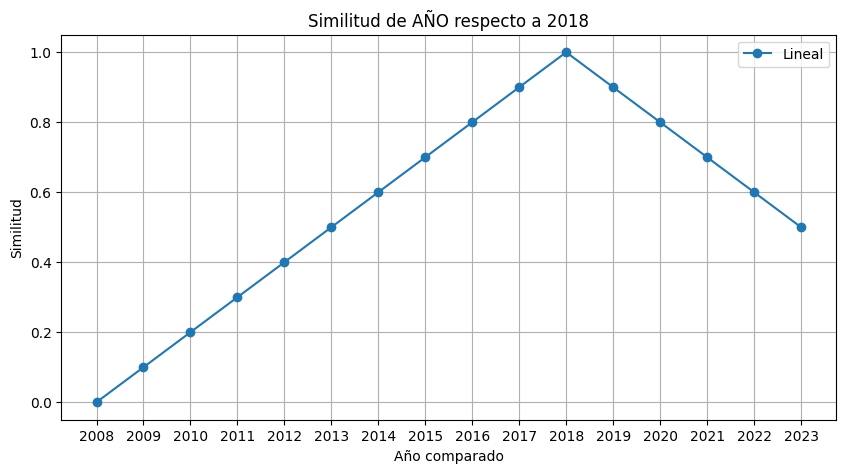

In [11]:
reference_year = 2018
years = list(range(2008, 2024))
year_sims = [year_sim_linear(reference_year, y) for y in years]
plot_year([year_sims], ['Lineal'], years, reference_year)

### **Ejercicio 1:** Comparación de métricas numéricas

Investiga las métricas numéricas `cbrkit.sim.numbers.exponential`, `cbrkit.sim.numbers.sigmoid`, `cbrkit.sim.numbers.threshold`.

1. Añadelas al código
2. Investiga los parámetros más apropiados.
3. ¿Cuál crees que es más apropiada para este dominio? Justifica tu respuesta en una celda de texto.

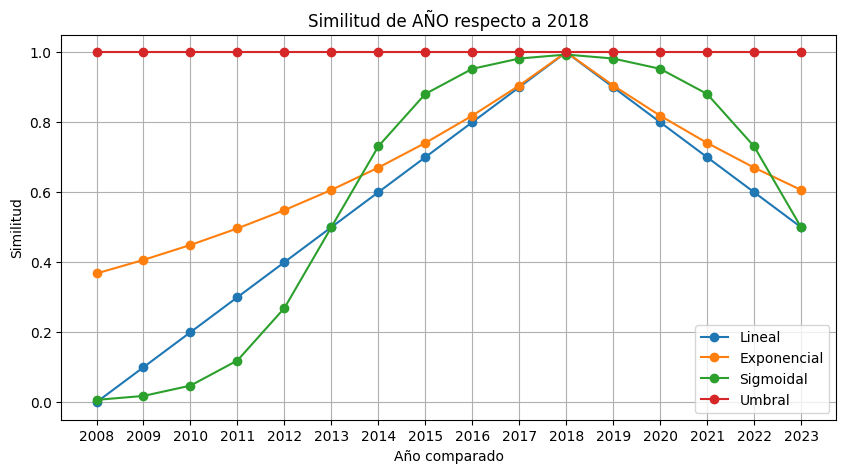

In [12]:
# Ejercicio 1: Tu código aquí
year_sim_exponential = cbrkit.sim.numbers.exponential(0.1) # Similitud exponencial: controla qué tan rápido decae la similitud con la diferencia de años. Un valor más alto hace que la similitud caiga más rápido.
year_sim_sigmoid = cbrkit.sim.numbers.sigmoid(1,5)  # Similitud sigmoidal: similitud en forma de S
year_sim_threshold = cbrkit.sim.numbers.threshold(10)  # similitud umbral. si la diferencia de años es menor que 10, similitud es 1.0, si es mayor o igual a 10, similitud es 0.0

# Compara las métricas
reference_year = 2018
years = list(range(2008, 2024))

linear_sims = [year_sim_linear(reference_year, y) for y in years]
exp_sims = [year_sim_exponential(reference_year, y) for y in years]
sig_sims = [year_sim_sigmoid(reference_year, y) for y in years]
thr_sims = [year_sim_threshold(reference_year, y) for y in years]


plot_year([linear_sims, exp_sims, sig_sims, thr_sims], ['Lineal', 'Exponencial', 'Sigmoidal', 'Umbral'], years, reference_year)



La mas apropiada en este caso podria ser la sigmoidal. Porque en este caso al estar hablando de años de coches este año representa tanto la tecnología como otras características importantes del mismo, por tanto, cuanto menos años de diferencia hayan con el año especificado es mejor. En este caso usamos una sigmoidal con los siguientes parámetros:
1 para transición moderada en la pendiente
5 para especificar que a partir de 5 años, el coche ya empieza a estar desfasado.
- Si utilizáramos la lineal, un coche de 2020 y uno de 2018 son igual de diferentes que uno de 2016 y uno de 2014. Pero en realidad, 2 años en un coche reciente importan más que 2 años en un coche antiguo.
- La exponencial penaliza demasiado rápido. Un Toyota camry de 2018 y uno de 2020 ya serían muy poco similares. Cuando son realmente parecidos.
- La umbral es demasiado rígida.

### 3.2 Métricas para atributos categóricos (`cbrkit.sim.generic`)

Para atributos como `fuel`, `transmission` o `condition` podemos usar:
- **`equality`**: 1.0 si son iguales, 0.0 si no lo son.
- **`table`**: define similitudes personalizadas entre pares de valores.
- Una función personalizada.

Esto se refiere a que hasta ahora hemos estado comparando números (años, kilómetros) pero también debemos comparar atributos que se categorizan.

In [13]:
# Métrica de igualdad (la más básica para categóricos) --> si son completamente iguales, similitud es 1.0, si no, es 0.0. No hay términos intermedios.
equality_sim = cbrkit.sim.generic.equality()

print("=== Similitud de COMBUSTIBLE (igualdad) ===")
fuels = [("gas", "gas"), ("gas", "electric"), ("gas", "hybrid"), ("electric", "electric")]
for x, y in fuels:
    print(f"  sim({x}, {y}) = {equality_sim(x, y):.1f}")

=== Similitud de COMBUSTIBLE (igualdad) ===
  sim(gas, gas) = 1.0
  sim(gas, electric) = 0.0
  sim(gas, hybrid) = 0.0
  sim(electric, electric) = 1.0


In [14]:
# Métrica de tabla: permite definir similitudes parciales entre valores categóricos
# Útil cuando hay una relación semántica entre las categorías
# Aquí nosotros definimos manualmente cuánto se parece cada valor a cada otro. Es como hacer una tabla de puntuaciones.

# Para el atributo 'condition', hay un orden natural: excellent > good > fair > salvage
condition_sim_table = cbrkit.sim.generic.table(
    {
        ("excellent", "excellent"): 1.0,
        ("excellent", "good"):      0.7,
        ("excellent", "fair"):      0.3,
        ("excellent", "salvage"):   0.0,
        ("good",      "excellent"): 0.7,
        ("good",      "good"):      1.0,
        ("good",      "fair"):      0.5,
        ("good",      "salvage"):   0.1,
        ("fair",      "excellent"): 0.3,
        ("fair",      "good"):      0.5,
        ("fair",      "fair"):      1.0,
        ("fair",      "salvage"):   0.2,
        ("salvage",   "excellent"): 0.0,
        ("salvage",   "good"):      0.1,
        ("salvage",   "fair"):      0.2,
        ("salvage",   "salvage"):   1.0,
    },
    default=0.0
)

print("=== Similitud de CONDICIÓN (tabla personalizada) ===")
conditions = ["excellent", "good", "fair", "salvage"]
for c1 in conditions:
    for c2 in conditions:
        sim = condition_sim_table(c1, c2)
        print(f"  sim({c1:10s}, {c2:10s}) = {sim:.1f}")

=== Similitud de CONDICIÓN (tabla personalizada) ===
  sim(excellent , excellent ) = 1.0
  sim(excellent , good      ) = 0.7
  sim(excellent , fair      ) = 0.3
  sim(excellent , salvage   ) = 0.0
  sim(good      , excellent ) = 0.7
  sim(good      , good      ) = 1.0
  sim(good      , fair      ) = 0.5
  sim(good      , salvage   ) = 0.1
  sim(fair      , excellent ) = 0.3
  sim(fair      , good      ) = 0.5
  sim(fair      , fair      ) = 1.0
  sim(fair      , salvage   ) = 0.2
  sim(salvage   , excellent ) = 0.0
  sim(salvage   , good      ) = 0.1
  sim(salvage   , fair      ) = 0.2
  sim(salvage   , salvage   ) = 1.0


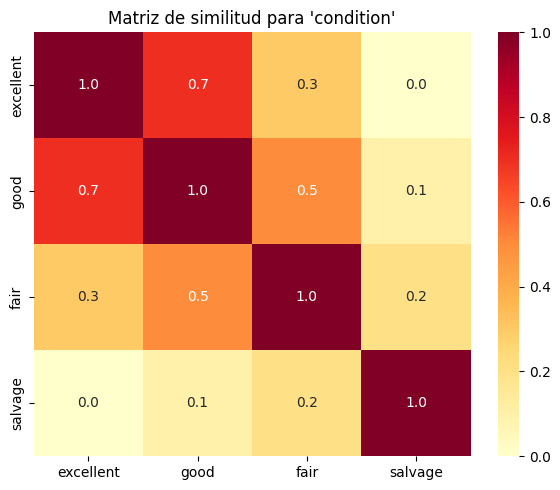

In [15]:
# Visualizar la matriz de similitud para 'condition'
conditions = ["excellent", "good", "fair", "salvage"]
matrix = [[condition_sim_table(c1, c2) for c2 in conditions] for c1 in conditions]
matrix_df = pd.DataFrame(matrix, index=conditions, columns=conditions)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Matriz de similitud para 'condition'")
plt.tight_layout()
plt.show()

### **Ejercicio 2:** Métrica para el atributo `fuel`

La igualdad exacta para `fuel` puede ser demasiado estricta. Por ejemplo, `hybrid` es más cercano a `electric` que a `gas`.

1. Crea una **métrica de tabla** para el atributo `fuel` que tenga en cuenta estas similitudes parciales.
2. Visualiza la matriz de similitud resultante.
3. Justifica tus elecciones de valores en una celda de texto.

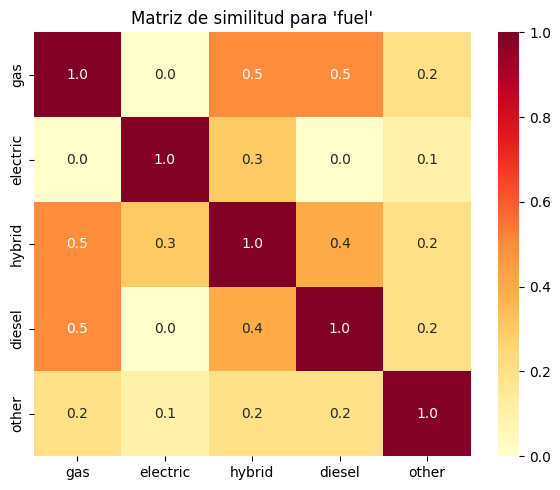

In [16]:
# Ejercicio 2: Tu código aquí
# Valores posibles de fuel: gas, electric, hybrid, diesel, other

fuel_sim = cbrkit.sim.generic.table(
    {
        ("gas", "gas"): 1.0, # Son iguales
        ("gas", "electric"): 0.0, # Son completamente diferentes
        ("gas", "hybrid"): 0.5, # Un híbrido es parcialmente similar a un coche de gasolina (50% gas, 50% eléctrico)
        ("gas", "diesel"): 0.5, # Un coche diésel es parcialmente similar a un coche de gasolina. Así con todos.
        ("gas", "other"): 0.2,
        ("electric", "electric"): 1.0,
        ("electric", "gas"): 0.0,
        ("electric", "hybrid"): 0.3,
        ("electric", "diesel"): 0.0,
        ("electric", "other"): 0.1,
        ("hybrid", "hybrid"): 1.0,
        ("hybrid", "gas"):0.5,
        ("hybrid", "electric"): 0.3,
        ("hybrid", "diesel"): 0.4,
        ("hybrid", "other"): 0.2,
        ("diesel", "diesel"): 1.0,
        ("diesel", "gas"): 0.5,
        ("diesel", "electric"): 0.0,
        ("diesel", "hybrid"): 0.4,
        ("diesel", "other"): 0.2,
        ("other", "other"): 1.0,
        
        ("other", "gas"): 0.2,
        ("other", "electric"): 0.1,
        ("other", "hybrid"): 0.2,
        ("other", "diesel"): 0.2,
    },
    default=0.0
)



# Visualiza la matriz de similitud
conditions = ["gas", "electric", "hybrid", "diesel", "other"]
matrix = [[fuel_sim(c1, c2) for c2 in conditions] for c1 in conditions]
matrix_df = pd.DataFrame(matrix, index=conditions, columns=conditions)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Matriz de similitud para 'fuel'")
plt.tight_layout()
plt.show()


*Escribe aquí tu justificación del Ejercicio 2...*
Para los valores que son iguales como (gas,gas) hemos elegido 1 porque son lo mismo, para combustibles que tienen similitudes como el gas y el diesel hemos puesto 0.5 que es la mitad de similitud y para combustibles poco similares u opuestos como gas y electric y other, hemos puesto o 0 o valores cercanos al 0 como 0.2.

### 3.3 Métricas para atributos de texto (`cbrkit.sim.strings`)

El atributo `model` es una cadena de texto libre (ej. "camry se", "camry xse"). Para compararlo usaremos métricas de similitud de strings:

In [17]:
# Métricas de similitud de cadenas disponibles en CBRkit
# Necesitamos instalar la dependencia 'nlp' de cbrkit para Levenshtein y Jaro
%pip install levenshtein --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:

# Métrica de Levenshtein: basada en distancia de edición. Está métrica consiste en:
#   - Contar el número mínimo de operaciones necesarias para transformar una cadena en otra.
#   - Las operaciones permitidas son: inserción, eliminación o sustitución de un carácter.
# Por ejemplo, para transformar "camry se" en "camry le", solo necesitamos una sustitución (cambiar 's' por 'l'), por lo que la distancia de Levenshtein es 1. Para transformar "camry se" en "corolla le", necesitamos varias operaciones (sustituir 'c' por 'c', 'a' por 'o', 'm' por 'r', etc.), lo que da una distancia mayor.
levenshtein_sim = cbrkit.sim.strings.levenshtein()

# Métrica de Jaro-Winkler: mejor para nombres y cadenas cortas. Esta métrica consiste en:
#   - Calcular la similitud basada en el número de caracteres coincidentes y el número de transposiciones.
#   - Da más peso a los caracteres que coinciden al principio de la cadena (lo que es útil para nombres).
jaro_sim = cbrkit.sim.strings.jaro_winkler()

print("=== Comparación de métricas de STRING para 'model' ===")
model_pairs = [
    ("camry se", "camry se"),       # igual
    ("camry se", "camry le"),       # muy similar (mismo modelo, trim diferente)
    ("camry se", "camry xse"),      # similar
    ("camry se", "corolla le"),     # misma marca, modelo diferente
    ("camry se", "f-150 xlt"),      # completamente diferente
]

print(f"{'Par':<35} {'Levenshtein':>12} {'Jaro-Winkler':>12}")
print("-" * 62)
for x, y in model_pairs:
    lev = levenshtein_sim(x, y)
    jaro = jaro_sim(x, y)
    print(f"  ({x!r}, {y!r})   {lev:>12.3f} {jaro:>12.3f}")

=== Comparación de métricas de STRING para 'model' ===
Par                                  Levenshtein Jaro-Winkler
--------------------------------------------------------------
  ('camry se', 'camry se')          1.000        1.000
  ('camry se', 'camry le')          0.875        0.950
  ('camry se', 'camry xse')          0.941        0.978
  ('camry se', 'corolla le')          0.444        0.633
  ('camry se', 'f-150 xlt')          0.118        0.412


**Para este dataset de coches, Jaro-Winkler es probablemente mejor porque los modelos suelen compartir prefijo ("camry se", "camry xse", "camry le") y eso es exactamente lo que Jaro-Winkler premia.**

In [33]:
# También podemos definir una función personalizada
# CBRkit exige que los parámetros se llamen x e y
# Nosotros definimos las regals basándonos en cómo funcionan los nombres de coches.

def model_sim_prefix(x: str, y: str) -> float:
    """
    Similitud para el modelo del coche:
    - Coincidencia exacta: 1.0
    - La primera palabra (nombre de modelo) coincide: 0.7. Si coincide el modelo del coche es similar.
    - La primera palabra NO coincide: basado en Jaro. No coincide el modelo entonces se parece muy poco.
    """
    if x == y:
        return 1.0
    x_parts = x.lower().split()
    y_parts = y.lower().split()
    if x_parts[0] == y_parts[0]:
        return 0.7
    # Si las primeras palabras son distintas, similitud baja
    return 0.1

print("=== Función personalizada 'model_sim_prefix' ===")
for x, y in model_pairs:
    sim = model_sim_prefix(x, y)
    print(f"  ({x!r}, {y!r}) => {sim:.2f}")

=== Función personalizada 'model_sim_prefix' ===
  ('camry se', 'camry se') => 1.00
  ('camry se', 'camry le') => 0.70
  ('camry se', 'camry xse') => 0.70
  ('camry se', 'corolla le') => 0.10
  ('camry se', 'f-150 xlt') => 0.10


---
## Parte 4: Pipeline de recuperación completo

Ahora combinaremos todas las métricas locales en un **pipeline de recuperación** usando `cbrkit.sim.attribute_value` para definir la similitud global, y `cbrkit.retrieval.build` para construir el retriever.

### 4.1 Primer retriever: similitud básica

In [35]:
# Definición del retriever básico
# attribute_value combina similitudes locales mediante media ponderada
# Esto es el corazón del sistema de Razonamiento Basado en Casos (CBR). Juntamos todas las métricas que hemos definido antes en una sola puntuación final. 

# Definimos cuáles son las métricas que utilizaremos para cada atributo y cómo las combinaremos (media ponderada)
base_retriever = cbrkit.retrieval.build(
    cbrkit.sim.attribute_value(
        attributes={
            "year":         year_sim_linear,
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         equality_sim,
            "transmission": equality_sim,
            "condition":    equality_sim,
            "model":        levenshtein_sim,
        },
        aggregator=cbrkit.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20, # El año es un atributo importante para determinar el precio, pero no es lo único que importa. Por eso le damos un peso del 20%.
            "odometer":     0.20, # Los kilometros también son muy importantes, ya que un coche con muchos kilómetros suele ser más barato. Le damos otro 20%.
            "manufacturer": 0.20, # La marca del coche también influye en el precio, algunas marcas son más caras que otras. Le damos otro 20%.
            "fuel":         0.10, # El tipo de combustible también afecta al precio, pero no tanto como los anteriores. 
            "transmission": 0.05, # El tipo de transmisión tiene un impacto menor en el precio, por eso le damos un peso más bajo.
            "condition":    0.15, # La condición del coche es importante, pero no tan determinante como el año, kilometraje o marca. Le damos un peso intermedio.
            "model":        0.10, # El modelo específico también influye en el precio, pero no tanto como la marca o el año. Le damos un peso del 10%..
        })
    )
)

# Devuelve de los 40 coches los 5 más similares al coche de la consulta
retriever_basic = cbrkit.retrieval.dropout(base_retriever, limit=5)
print("Retriever básico construido")

Retriever básico construido


In [ ]:
# Ejecutar la recuperación para la primera consulta
# 1. Se imprime el coche que se está buscando (año, marca, modelo, condición y kilometraje).
query = queries["query_1"]
print(f"Consulta: {query['year']} {query['manufacturer']} {query['model']}")
print(f"         Condición: {query['condition']}, Kilometraje: {query['odometer']:,}\n")

# 2. Se ejecuta la recuperación utilizando el retriever básico definido anteriormente. Compara query con los 40 coches. Calcula la similitud de cada coche con la consulta utilizando las 
# métricas definidas para cada atributo, y luego combina esas similitudes en una puntuación final para cada coche. Finalmente, devuelve los 5 coches más similares a la consulta.
result = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_basic)

# CBRkit guarda el proceso en "pasos" (steps). Con [-1] cogemos el último paso, que es el resultado final. Luego extraemos la información de tu consulta específica.
# De qstep puedes sacar:
#       - qstep.ranking — lista de IDs ordenados por similitud (el mejor primero)
#       - qstep.similarities[case_id].value — similitud exacta de cada coche
step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

Consulta: 2018 toyota camry le
         Condición: good, Kilometraje: 50,000

  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9808
   5  2017       toyota             corolla le   13,500     0.9302
  39  2014       toyota          highlander le   18,000     0.8316
  13  2019       toyota               rav4 xle   27,000     0.7453
  30  2020       toyota              camry xse   26,000     0.7417


In [22]:
(a, b) = result
b

('duration', 0.004634083998098504)

### 4.2 Segundo retriever: métricas mejoradas

Ahora construiremos un segundo retriever que use las métricas más elaboradas que hemos definido.

In [37]:
# Retriever mejorado con las métricas personalizadas
# NOTA: Antes de ejecutar esto, asegúrate de haber completado el Ejercicio 2
# Si no, puedes usar equality_sim para fuel como placeholder

base_retriever_improved = cbrkit.retrieval.build(
    cbrkit.sim.attribute_value(
        attributes={
            "year":         year_sim_exponential,   # función exponencial personalizada.. Los años recientes importan más que los lejanos
            "odometer":     odometer_sim_linear, 
            "manufacturer": equality_sim,
            "fuel":         fuel_sim,                # tabla de similitud personalizada para el tipo de combustible. Un coche híbrido es parcialmente similar a un coche de gasolina, etc. LO que hemos hecho con Adri en clase.
            "transmission": equality_sim,
            "condition":    condition_sim_table,     # tabla de similitud semántica. Good y excellent se parecen, no son 0 y 1.
            "model":        model_sim_prefix,        # Entiende la estructura real del nombre del coche.
        },
        aggregator=cbrkit.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20,
            "odometer":     0.20,
            "manufacturer": 0.20,
            "fuel":         0.10,
            "transmission": 0.05,
            "condition":    0.15,
            "model":        0.10,
        })
    )
)


retriever_improved = cbrkit.retrieval.dropout(base_retriever_improved, limit=5)
print("Retriever mejorado construido")


result = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_improved)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]


print("Top-5 con retriever MEJORADO:")
step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

Retriever mejorado construido
Top-5 con retriever MEJORADO:
  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9633
   5  2017       toyota             corolla le   13,500     0.8856
  30  2020       toyota              camry xse   26,000     0.8381
  13  2019       toyota               rav4 xle   27,000     0.8113
  39  2014       toyota          highlander le   18,000     0.8081


### **Ejercicio 3:** Comparación de retrievers

1. Ejecuta ambos retrievers (básico y mejorado) sobre otras tres consultas distintas.
2. Para cada consulta, muestra una tabla comparando el top-3 recuperado por cada retriever.
3. ¿Los resultados difieren significativamente? ¿Cuándo las mejoras son más notables?
Sí, los resultados difieren significativamente en varios casos, el retriever mejorado recupera casos más relevantes al capturar similitudes parciales en lugar de exigir igualdad exacta. Las mejoras son más notables en consultas donde los atributos clave tienen variaciones semánticas o no lineales.

In [45]:
def compare_retrievers(query_key, limit=3):
    query = queries[query_key]
    print(f"\n{'-'*70}")
    print(f"CONSULTA ({query_key}): {query['year']} {query['manufacturer']} {query['model']}")
    print(f"Condición: {query['condition']} | Kilometraje: {query['odometer']:,} | Combustible: {query['fuel']}")
    print(f"{'-'*70}")

    # Ejecutar ambos retrievers
    result_basic    = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_basic)
    result_improved = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_improved)

    qstep_basic    = list(result_basic.steps[-1].queries.values())[0]
    qstep_improved = list(result_improved.steps[-1].queries.values())[0]

    ranking_basic    = qstep_basic.ranking[:limit]
    ranking_improved = qstep_improved.ranking[:limit]

    # Cabecera
    col = f"{'#':>2} {'ID':>3} {'Año':>5} {'Marca':>10} {'Modelo':>18} {'Sim':>7}"
    sep = "-" * len(col)
    print(f"\n{'RETRIEVER BÁSICO':<45}  {'       RETRIEVER MEJORADO'}")
    print(f"{col}  {col}")
    print(f"{sep}  {sep}")

    for i, (id_b, id_m) in enumerate(zip(ranking_basic, ranking_improved), 1):
        sim_b = float(qstep_basic.similarities[id_b].value)
        sim_m = float(qstep_improved.similarities[id_m].value)
        cb = casebase[id_b]
        cm = casebase[id_m]

        fila_b = f"{i:>2} {id_b:>3} {cb['year']:>5} {cb['manufacturer']:>10} {cb['model']:>18} {sim_b:>7.4f}"
        fila_m = f"{i:>2} {id_m:>3} {cm['year']:>5} {cm['manufacturer']:>10} {cm['model']:>18} {sim_m:>7.4f}"

        # Resaltar si devuelven coches distintos
        marca = " (Distintos)" if id_b != id_m else "  "
        print(f"{fila_b}  {fila_m}{marca}")

    print()

# Ejecutar para las 3 consultas
for q in ["query_1", "query_2", "query_3"]:
    compare_retrievers(q, limit=3)


----------------------------------------------------------------------
CONSULTA (query_1): 2018 toyota camry le
Condición: good | Kilometraje: 50,000 | Combustible: gas
----------------------------------------------------------------------

RETRIEVER BÁSICO                                      RETRIEVER MEJORADO
 #  ID   Año      Marca             Modelo     Sim   #  ID   Año      Marca             Modelo     Sim
--------------------------------------------------  --------------------------------------------------
 1   0  2018     toyota           camry se  0.9808   1   0  2018     toyota           camry se  0.9633  
 2   5  2017     toyota         corolla le  0.9302   2   5  2017     toyota         corolla le  0.8856  
 3  39  2014     toyota      highlander le  0.8316   3  30  2020     toyota          camry xse  0.8381 (Distintos)


----------------------------------------------------------------------
CONSULTA (query_2): 2020 tesla model 3 long range
Condición: excellent | Kilometr

*Escribe aquí tu análisis del Ejercicio 3...*

Los resultados son bastante distintos a nivel similitudes entre lo que muestra el retriever mejorado y el retriever normal a pesar de que en todos ellos se muestran los mismos coches en las dos primeras filas. En el caso de la primera y segunda query, se traen coches distintos en la tercera fila. En la query 1 se puede ver que el retriever mejorado trae un coche más parecido porque el modelo es más parecido (camryvs highlander). Por lo que el retriever mejorado trae un coche más parecido. Además, en general, las similutudes que trae el retriever mejorado son mayores que el retriever normal y esto se puede ver sobre todo en los resultados de la tercera query.

### **Ejercicio 4:** Efecto de los pesos en el retrieval

Los pesos en `pooling_weights` controlan la importancia relativa de cada atributo en la similitud global.

1. Crea un tercer retriever `retriever_km_focused` donde el kilometraje tenga un peso de **0.40** (reduce los otros atributos proporcionalmente).
2. Compara sus resultados con el retriever mejorado para `query_3` (el coche con mayor kilometraje).
3. ¿Qué atributos tienen mayor impacto en los resultados?

In [55]:
# Ejercicio 4: Tu código aquí
retriever_km_focused = cbrkit.retrieval.build(
    cbrkit.sim.attribute_value(
        attributes={
            "year":         year_sim_linear,
            "odometer":     odometer_sim_linear, # Nos centramos solo en el kilometraje. Queremos ver qué coches tienen un kilometraje similar al de la consulta, sin importar tanto el año, marca o modelo.
            "manufacturer": equality_sim,
            "fuel":         fuel_sim,
            "transmission": equality_sim,
            "condition":    condition_sim_table,
            "model":        model_sim_prefix,
        },
        aggregator=cbrkit.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.13, 
            "odometer":     0.40, 
            "manufacturer": 0.13, 
            "fuel":         0.07, 
            "transmission": 0.03, 
            "condition":    0.14, 
            "model":        0.10,
        }),
    )
)


# Compara para query_3

retriever_km_focused = cbrkit.retrieval.dropout(retriever_km_focused, limit=5)
print("Retriever KM-Focused construido")
print(f"Suma de pesos: {0.13+0.40+0.13+0.07+0.03+0.14+0.10:.2f}") #En total suma 1! 


query = queries["query_3"]
print(f"\n{'-'*70}")
print(f"CONSULTA (query_3): {query['year']} {query['manufacturer']} {query['model']}")
print(f"Condición: {query['condition']} | Kilometraje: {query['odometer']:,} | Combustible: {query['fuel']}")
print(f"{'-'*70}")


# Ejecutar ambos retrievers
result_improved = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_improved)
result_km_focused = cbrkit.retrieval.apply.apply_query(casebase, query, retriever_km_focused)

qstep_improved = list(result_improved.steps[-1].queries.values())[0]
qstep_km_focused = list(result_km_focused.steps[-1].queries.values())[0]

ranking_improved = qstep_improved.ranking[:5]
ranking_km_focused = qstep_km_focused.ranking[:5]


# Cabecera
col = f"{'#':>2} {'ID':>3} {'Año':>5} {'Marca':>10} {'Modelo':>18} {'Odo':>8} {'Sim':>7}"
sep = "-" * len(col)
print(f"\n{'RETRIEVER MEJORADO':<50}  {'          RETRIEVER KM-FOCUSED'}")
print(f"{col}  {col}")
print(f"{sep}  {sep}")

for i, (id_m, id_k) in enumerate(zip(ranking_improved, ranking_km_focused), 1):
    sim_m = float(qstep_improved.similarities[id_m].value)
    sim_k = float(qstep_km_focused.similarities[id_k].value)
    cm = casebase[id_m]
    ck = casebase[id_k]

    fila_m = f"{i:>2} {id_m:>3} {cm['year']:>5} {cm['manufacturer']:>10} {cm['model']:>18} {cm['odometer']:>8,} {sim_m:>7.4f}"
    fila_k = f"{i:>2} {id_k:>3} {ck['year']:>5} {ck['manufacturer']:>10} {ck['model']:>18} {ck['odometer']:>8,} {sim_k:>7.4f}"

    marca = " (Distintos)" if id_m != id_k else "  "
    print(f"{fila_m}  {fila_k}{marca}")

Retriever KM-Focused construido
Suma de pesos: 1.00

----------------------------------------------------------------------
CONSULTA (query_3): 2015 honda civic ex
Condición: fair | Kilometraje: 85,000 | Combustible: gas
----------------------------------------------------------------------

RETRIEVER MEJORADO                                            RETRIEVER KM-FOCUSED
 #  ID   Año      Marca             Modelo      Odo     Sim   #  ID   Año      Marca             Modelo      Odo     Sim
-----------------------------------------------------------  -----------------------------------------------------------
 1   1  2016      honda           civic lx   62,000  0.8453   1   1  2016      honda           civic lx   62,000  0.8257  
 2  21  2015      honda             fit lx   66,000  0.8097   2   6  2014      honda       accord sport   78,000  0.8083 (Distintos)
 3   6  2014      honda       accord sport   78,000  0.8066   3  21  2015      honda             fit lx   66,000  0.7893 (Dist

Vemos en el resultado de la consulta que se muestran para el retriever de km coches priorizando un odómetro parecido al de la consulta a pesar de que las marcas de coches sean completamente distintas.

---
## Parte 5: Adaptación de la solución (Reuse)

Una vez recuperados los casos más similares, la etapa de **Reuse** adapta su solución al nuevo problema. En nuestro dominio, la "solución" es el **precio** del vehículo.

Implementaremos una función de adaptación que **estima el precio** del vehículo consulta en base a los casos recuperados.

### 5.1 Adaptación simple: media ponderada de precios

In [25]:
# Función de adaptación: media ponderada de precios por similitud
# En CBRkit, una función de reuse acepta (case, query) y devuelve el caso adaptado

def adapt_price_weighted_mean(case: dict, query: dict) -> dict:
    """
    Adaptación trivial: devuelve el precio del caso más similar sin modificación.
    Este es el caso más simple de reuse (copia directa).
    """
    adapted = dict(case)  # copia del caso
    # El precio no se adapta, se reutiliza directamente
    return adapted

print("Función de adaptación básica definida")

# Construcción del pipeline completo: retrieval + reuse
reuser_basic = cbrkit.reuse.build(adapt_price_weighted_mean, retriever_basic)
print("Reuser construido")

Función de adaptación básica definida
Reuser construido


In [56]:
# Pipeline completo: primero retrieve, luego reuse
query = queries["query_1"]


# Paso 2: Reuse (adaptación trivial - precio directo)
reuse_result = cbrkit.reuse.apply.apply_query(casebase, query, reuser_basic)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")


  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9633
   5  2017       toyota             corolla le   13,500     0.8856
  30  2020       toyota              camry xse   26,000     0.8381
  13  2019       toyota               rav4 xle   27,000     0.8113
  39  2014       toyota          highlander le   18,000     0.8081


In [27]:
reuse_result

Result(steps=[ResultStep[TypeVar, TypeVar, TypeVar, TypeVar](queries={'default': QueryResultStep[TypeVar, TypeVar, TypeVar](similarities={0: AttributeValueSim(value=np.float64(0.9808333333333333), attributes={'year': np.float64(1.0), 'odometer': np.float64(0.9666666666666667), 'manufacturer': 1.0, 'fuel': 1.0, 'transmission': 1.0, 'condition': 1.0, 'model': 0.875}), 5: AttributeValueSim(value=np.float64(0.9302222222222223), attributes={'year': np.float64(0.9), 'odometer': np.float64(0.9733333333333334), 'manufacturer': 1.0, 'fuel': 1.0, 'transmission': 1.0, 'condition': 1.0, 'model': 0.5555555555555556}), 39: AttributeValueSim(value=np.float64(0.8316190476190476), attributes={'year': np.float64(0.6), 'odometer': np.float64(0.82), 'manufacturer': 1.0, 'fuel': 1.0, 'transmission': 1.0, 'condition': 1.0, 'model': 0.47619047619047616}), 13: AttributeValueSim(value=np.float64(0.7453333333333334), attributes={'year': np.float64(0.9), 'odometer': np.float64(0.8266666666666667), 'manufacturer'

### **Ejercicio 5:** Implementa tu propia función de adaptación

La función de adaptación anterior solo considera año, kilometraje y condición. Mejórala añadiendo:

1. Una corrección cuando el **tipo de combustible** es diferente (ej., los coches eléctricos suelen ser más caros que los de gasolina equivalentes).
2. Una corrección cuando el **fabricante** es distinto (ej., marcas de lujo como BMW tienen precios más altos).
3. Prueba tu función de adaptación mejorada en las tres consultas y compara los precios estimados con la versión anterior.

In [66]:
# Ejercicio 5: Implementación completa

FUEL_PRICE_FACTOR = {
    "electric": 1.15,
    "hybrid":   1.05,
    "gas":      1.00,
    "diesel":   1.02,
    "other":    0.95,
}

MANUFACTURER_TIER = {
    "bmw":        1.20,
    "tesla":      1.20,
    "audi":       1.20,
    "lexus":      1.20,
    "toyota":     1.00,
    "honda":      1.00,
    "volkswagen": 1.00,
    "subaru":     1.00,
    "ford":       0.90,
    "chevrolet":  0.90,
    "nissan":     0.90,
    "hyundai":    0.90,
    "kia":        0.90,
}

def adapt_price_advanced_v2(case: dict, query: dict) -> dict:
    """
    Adaptación mejorada del precio base con 4 correcciones:
      1. Año       → los coches más nuevos valen más
      2. Km        → más kilómetros bajan el precio
      3. Fuel      → eléctrico/híbrido tienen prima de precio
      4. Marca     → marcas premium valen más que las budget
    """
    base_price = case["price"]

    # --- Corrección 1: Año ---
    # Cada año de diferencia ajusta el precio un 3%
    year_diff = query["year"] - case["year"]
    year_factor = 1 + (year_diff * 0.03)          # +3% por año más nuevo, -3% por año más viejo

    # --- Corrección 2: Kilometraje ---
    # Cada 10,000 km de diferencia ajusta el precio un 2%
    km_diff = case["odometer"] - query["odometer"]
    km_factor = 1 + (km_diff / 10000 * 0.02)      # +2% si la query tiene menos km

    # --- Corrección 3: Combustible ---
    # Si el combustible es distinto, ajustamos por el factor relativo
    fuel_case  = FUEL_PRICE_FACTOR.get(case["fuel"],  1.00)
    fuel_query = FUEL_PRICE_FACTOR.get(query["fuel"], 1.00)
    fuel_factor = fuel_query / fuel_case           # ratio entre lo que buscas y lo que hay

    # --- Corrección 4: Fabricante ---
    manuf_case  = MANUFACTURER_TIER.get(case["manufacturer"],  1.00)
    manuf_query = MANUFACTURER_TIER.get(query["manufacturer"], 1.00)
    manuf_factor = manuf_query / manuf_case        # ratio entre marcas

    # --- Precio final ---
    adapted_price = base_price * year_factor * km_factor * fuel_factor * manuf_factor
    adapted_price = max(0, round(adapted_price, 2))  # nunca negativo

    # Devolvemos el caso adaptado con el precio nuevo
    adapted = dict(case)
    adapted["price"] = adapted_price
    adapted["_price_original"]  = base_price       # guardamos el original para comparar
    adapted["_year_factor"]     = round(year_factor, 4)
    adapted["_km_factor"]       = round(km_factor, 4)
    adapted["_fuel_factor"]     = round(fuel_factor, 4)
    adapted["_manuf_factor"]    = round(manuf_factor, 4)
    return adapted


# --- Pipeline completo ---
reuser_v1 = cbrkit.reuse.build(adapt_price_weighted_mean, retriever_improved)
reuser_v2 = cbrkit.reuse.build(adapt_price_advanced_v2,   retriever_improved)


# --- Comparación en las 3 consultas ---
def compare_adaptation(query_key):
    query = queries[query_key]
    print(f"\n{'='*65}")
    print(f"CONSULTA ({query_key}): {query['year']} {query['manufacturer']} {query['model']}")
    print(f"Fuel: {query['fuel']} | Km: {query['odometer']:,} | Condición: {query['condition']}")
    print(f"{'='*65}")

    result_v1 = cbrkit.reuse.apply.apply_query(casebase, query, reuser_v1)
    result_v2 = cbrkit.reuse.apply.apply_query(casebase, query, reuser_v2)

    dq_v1 = result_v1.final_step.default_query
    dq_v2 = result_v2.final_step.default_query

    # Media ponderada manual usando los 5 casos adaptados
    def weighted_price(dq):
        total_sim, total_price = 0, 0
        for case_id, case in dq.casebase.items():
            sim = float(dq.similarities[case_id].value)
            total_sim   += sim
            total_price += sim * case["price"]
        return total_price / total_sim if total_sim > 0 else 0

    price_v1 = weighted_price(dq_v1)
    price_v2 = weighted_price(dq_v2)

    # Mostrar detalle del caso más similar (el primero del ranking)
    best_id = dq_v2.ranking[0]
    best    = dq_v2.casebase[best_id]

    print(f"\n  Caso más similar (ID {best_id}): "
        f"{best['year']} {best['manufacturer']} {best['model']}")
    print(f"  Precio original:  {float(best['_price_original']):>10,.2f}")
    print(f"  ─ Factor año      ({query['year']} vs {best['year']}): x {best['_year_factor']}")
    print(f"  ─ Factor km       ({query['odometer']:,} vs {int(best['odometer']):,}): x{best['_km_factor']}")
    print(f"  ─ Factor fuel     ({query['fuel']} vs {best['fuel']}): x{best['_fuel_factor']}")
    print(f"  ─ Factor marca    ({query['manufacturer']} vs {best['manufacturer']}): x{best['_manuf_factor']}")

    print(f"\n  Precio estimado BÁSICO:    ${price_v1:>10,.2f}")
    print(f"  Precio estimado MEJORADO:  ${price_v2:>10,.2f}")
    diff = price_v2 - price_v1

for q in ["query_1", "query_2", "query_3"]:
    compare_adaptation(q)


CONSULTA (query_1): 2018 toyota camry le
Fuel: gas | Km: 50,000 | Condición: good

  Caso más similar (ID 0): 2018 toyota camry se
  Precio original:   18,500.00
  ─ Factor año      (2018 vs 2018): x 1.0
  ─ Factor km       (50,000 vs 45,000): x0.99
  ─ Factor fuel     (gas vs gas): x1.0
  ─ Factor marca    (toyota vs toyota): x1.0

  Precio estimado BÁSICO:    $ 20,438.84
  Precio estimado MEJORADO:  $ 20,038.96

CONSULTA (query_2): 2020 tesla model 3 long range
Fuel: electric | Km: 10,000 | Condición: excellent

  Caso más similar (ID 7): 2021 tesla model 3 standard
  Precio original:   38,000.00
  ─ Factor año      (2020 vs 2021): x 0.97
  ─ Factor km       (10,000 vs 8,000): x0.996
  ─ Factor fuel     (electric vs electric): x1.0
  ─ Factor marca    (tesla vs tesla): x1.0

  Precio estimado BÁSICO:    $ 37,085.22
  Precio estimado MEJORADO:  $ 45,161.15

CONSULTA (query_3): 2015 honda civic ex
Fuel: gas | Km: 85,000 | Condición: fair

  Caso más similar (ID 1): 2016 honda civic lx

*Escribe aquí tu análisis del Ejercicio 5...*
adapt_price_advanced_v2 añade las dos mejoras pedidas(fuel y manufacturer) y nos permite comparar con la versión anterior. Solo tenemos que revisar que no se pierda la condición y puede que ajustar la linealidad de los factores para que el modelo sea más realista.

---
## Parte 7: Preguntas de reflexión

Responde a las siguientes preguntas en celdas de texto adicionales:

**Q1.** ¿Qué ventajas tiene usar una tabla de similitud semántica para `condition` frente a la igualdad exacta? ¿Puedes pensar en algún dominio donde la igualdad exacta sea siempre la opción correcta?

**Q2.** Los pesos de los atributos modelan la importancia relativa de cada uno. Si el sistema está orientado a compradores que priorizan el ahorro de combustible, ¿cómo modificarías los pesos?

**Q3.** La función de adaptación asume una depreciación lineal por año y por kilómetro. ¿Es esta una suposición razonable? ¿Qué modelo de depreciación sería más realista?

**Q4.** ¿Cómo implementarías la fase de **Retain** en este sistema? ¿Bajo qué condiciones añadirías un nuevo caso a la base?

**Q5.** CBRkit soporta embedding semántico (`cbrkit.sim.embed`) para comparar textos. ¿En qué situaciones del dominio del coche podría ser útil? ¿Qué limitaciones tendría?

**Q1.** Con igualdad exacta, un coche excellent y uno good tienen 0 de similitud (como si fueran completamente distintos). Sin embargo, algo se paracen, o por lo menos good y excellentent tienen una similitud mayor que excellent y otras categorias peores. Para la segunda parte, igualdad exacta lo podemos usar en colores por ejemplo o nacionalidades.

**Q2.** Pues le daría más importancia quizás al atributo fuel y al atributo odometer y reduciría otros menos importantes.

**Q3.** No es razonable porque la realidad es que los coches se deprecian de forma exponencial, pierden más valor el primer año de uso. Los siguientes años la caída se frena y a partir de cierta antigüedad el valor casi no baja. Un modelo más realista sería: year_factor = 0.8^year_diff

**Q4.** La fase Retain (retención) decide si el coche que tasamos merece guardarse en la base para futuras consultas. No se añadirian todos los casos, solo los que aporten información nueva.  (re)
Las condiciones razonables serían:

- Similitud máxima baja (ej. < 0.75): si ningún caso existente se parece mucho, este caso es valioso porque cubre un hueco.
- El precio real es muy diferente al estimado: indica que la base no tenía buena cobertura para ese tipo de coche.
- El caso es verificado: no añadir cualquier consulta, solo las que tienen un precio real confirmado.

**Q5.** Por ejemplo lo utilizaría para compararr descripciones de los coches donde "muy buen estado, un solo dueño" y "excelente conservación, propietario único" tendría en Levenshtein similitudes muy distintas pero con embedding serían muy similares. Pero:
  - Es mucho más lento y costoso
  - Necesita un modelo de lenguaje preentrenado.
  - Más útil en un dataset mucho más grande que los 40 vehiculos que tenemos nostros en este ejemplo.
  